# Thesis EDA: Session Timing, Baselines, and Discussion-Only Features

This notebook reproduces the timing audit and applies its discussion-onset boundaries to feature tables used in the thesis. It is intentionally independent of the ICMI and paper directories.

**Scope**

- Recover or load phase timing, with explicit provenance and QC flags.
- Audit T0 `free_talk` baselines and block-versus-discussion duration.
- Compare audio features before and after discussion-only filtering.
- Filter the current collective 30 s matrix and export deterministic timing tables.

All outputs retain only anonymized group and participant identifiers.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

PROJECT_ROOT = Path.cwd().resolve().parent
if not (PROJECT_ROOT / "analysis").is_dir():
    raise RuntimeError("Run this notebook with its working directory set to analysis/.")

RESULTS_DIR = PROJECT_ROOT / "analysis" / "results"
TIMING_DIR = RESULTS_DIR / "session_timing"
FEATURES_DIR = RESULTS_DIR / "collective_features_v20260812"
OUTPUT_DIR = RESULTS_DIR / "thesis_eda"
OUTPUT_DIR.mkdir(exist_ok=True)

TABLES = {
    "task_timing": TIMING_DIR / "task_timing.tsv",
    "phase_timing": TIMING_DIR / "phase_timing.tsv",
    "baseline_comparison": TIMING_DIR / "baseline_comparison.tsv",
    "audio_participant": RESULTS_DIR / "participant_audio_features.tsv",
    "collective_windows": FEATURES_DIR / "collective_window_features.tsv",
    "transcript_group_task": RESULTS_DIR / "transcript_features_full" / "transcript_group_task.tsv",
    "group_dynamics": RESULTS_DIR / "cross_modal" / "features_group_dynamics_task.tsv",
    "semantic_biomarkers": RESULTS_DIR / "cross_modal" / "semantic_biomarkers_participant_task.tsv",
    "participant_traits": RESULTS_DIR / "participant_traits.tsv",
}


def read_tsv_if_available(path: Path) -> pd.DataFrame | None:
    """Load a TSV table or return None when its generated output is unavailable."""
    return pd.read_csv(path, sep="\t") if path.exists() else None


tables = {name: read_tsv_if_available(path) for name, path in TABLES.items()}
availability = pd.DataFrame(
    {
        "table": TABLES.keys(),
        "path": [str(path.relative_to(PROJECT_ROOT)) for path in TABLES.values()],
        "available": [table is not None for table in tables.values()],
        "rows": [len(table) if table is not None else 0 for table in tables.values()],
    }
)
availability.to_csv(OUTPUT_DIR / "input_availability.tsv", sep="\t", index=False)
availability

,table,path,available,rows
0,task_timing,analysis\results\session_timing\task_timing.tsv,True,50
1,phase_timing,analysis\results\session_timing\phase_timing.tsv,True,198
2,baseline_comparison,analysis\results\session_timing\baseline_compa...,True,20
3,audio_participant,analysis\results\participant_audio_features.tsv,True,108
4,collective_windows,analysis\results\collective_features_v20260812...,True,1580
5,transcript_group_task,analysis\results\transcript_features_full\tran...,True,37
6,group_dynamics,analysis\results\cross_modal\features_group_dy...,True,745
7,semantic_biomarkers,analysis\results\cross_modal\semantic_biomarke...,True,196
8,participant_traits,analysis\results\participant_traits.tsv,True,40


## 1. Set Up Paths and Load Source Tables

The canonical `task_timing.tsv` and `phase_timing.tsv` tables are the reproducible outputs of phase-marker parsing. This notebook retains their source/QC information and reports whether raw event files are locally available for an independent rerun.

In [2]:
task_timing = tables["task_timing"]
phase_timing = tables["phase_timing"]

if task_timing is None or phase_timing is None:
    raise FileNotFoundError(
        "The timing audit requires analysis/results/session_timing/task_timing.tsv "
        "and phase_timing.tsv. Run tools/features/extract_session_timing.py first."
    )

required_task_columns = {"group_id", "task", "task_duration_s", "discussion_onset_s", "discussion_duration_s"}
required_phase_columns = {"group_id", "task", "phase", "onset_s"}
missing_task_columns = required_task_columns - set(task_timing.columns)
missing_phase_columns = required_phase_columns - set(phase_timing.columns)
if missing_task_columns or missing_phase_columns:
    raise ValueError(
        f"Unexpected timing schema. Task missing: {sorted(missing_task_columns)}; "
        f"phase missing: {sorted(missing_phase_columns)}"
    )

raw_event_roots = [PROJECT_ROOT / "data", PROJECT_ROOT / "bids", PROJECT_ROOT / "derivatives"]
raw_event_files = [
    path
    for root in raw_event_roots
    if root.exists()
    for path in root.rglob("*_events.tsv")
]
print(f"Found {len(raw_event_files)} raw event files in local data roots.")
print("Using canonical generated timing tables; their source/QC columns preserve fallback provenance.")

phase_timing = phase_timing.rename(columns={"task": "task_id", "onset_s": "phase_onset_s"})
task_timing = task_timing.rename(columns={"task": "task_id", "task_duration_s": "block_duration_s"})
phase_timing.head()

Found 0 raw event files in local data roots.
Using canonical generated timing tables; their source/QC columns preserve fallback provenance.


,session_id,group_id,task_id,phase,phase_onset_s,duration_s,expected_discussion_phase,is_discussion_start
0,ses-20260312_grp-07_run01,grp-07,T0,study_introduction,572.1,188.1,free_talk,False
1,ses-20260312_grp-07_run01,grp-07,T0,vad_introduction,760.2,100.3,free_talk,False
2,ses-20260312_grp-07_run01,grp-07,T0,postblock_introduction,860.5,16.2,free_talk,False
3,ses-20260312_grp-07_run01,grp-07,T0,free_talk,876.7,206.3,free_talk,True
4,ses-20260312_grp-07_run01,grp-07,T0,finish,1083.0,0.0,free_talk,False


## 2-13. Timing Derivation, Baseline Audit, Filtering, QC, and Exports

The cells below use the canonical generated timing tables when raw BIDS event files are not available locally. Optional feature tables are never substituted with historical ICMI outputs.

In [3]:
DISCUSSION_PHASES = {
    "T0": "free_talk", "T1": "discussion_selection", "T2": "role_card",
    "T3": "show_ideas_discussion", "T4": "discussion",
}

# Sections 2-5: phase provenance, discussion duration, and non-discussion overhead.
phase_timing["expected_discussion_phase"] = phase_timing["task_id"].map(DISCUSSION_PHASES)
phase_timing["is_discussion_start"] = phase_timing["phase"].eq(phase_timing["expected_discussion_phase"])
task_timing["expected_discussion_phase"] = task_timing["task_id"].map(DISCUSSION_PHASES)
task_timing["overhead_s"] = task_timing["block_duration_s"] - task_timing["discussion_duration_s"]
task_timing["overhead_pct"] = 100 * task_timing["overhead_s"] / task_timing["block_duration_s"]

discussion_summary = (
    task_timing.dropna(subset=["discussion_duration_s"])
    .groupby("task_id", as_index=False)
    .agg(
        n=("discussion_duration_s", "count"), mean_s=("discussion_duration_s", "mean"),
        sd_s=("discussion_duration_s", "std"), min_s=("discussion_duration_s", "min"),
        max_s=("discussion_duration_s", "max"),
    )
)
discussion_summary["mean_min"] = discussion_summary["mean_s"] / 60
overhead_summary = task_timing.groupby("task_id", as_index=False).agg(
    mean_overhead_s=("overhead_s", "mean"), mean_overhead_pct=("overhead_pct", "mean")
)

# Sections 6-7: valid 3-10 minute T0 free-talk periods are preferred baselines.
t0_free_talk = phase_timing.loc[
    (phase_timing["task_id"] == "T0") & (phase_timing["phase"] == "free_talk"),
    ["session_id", "group_id", "phase_onset_s", "duration_s"],
].rename(columns={"phase_onset_s": "free_talk_onset_s", "duration_s": "free_talk_duration_s"})
t0_free_talk["free_talk_offset_s"] = t0_free_talk["free_talk_onset_s"] + t0_free_talk["free_talk_duration_s"]
t0_free_talk["baseline_method"] = np.where(
    t0_free_talk["free_talk_duration_s"].between(180, 600), "free_talk", "whole_t0_fallback"
)
baseline_comparison = tables["baseline_comparison"]

# Sections 8-10: filter only a current analysis/results audio-window table; never use paper outputs.
audio_window_path = next((path for path in [
    RESULTS_DIR / "participant_audio_features_ALL_WINDOWS.tsv",
    RESULTS_DIR / "audio" / "individual_audio_windows.tsv",
] if path.exists()), None)
audio_before_after = pd.DataFrame()
audio_duration_correlations = pd.DataFrame(
    columns=["version", "task_id", "feature", "n", "pearson_r", "p_value"]
)
if audio_window_path is not None:
    audio_windows = pd.read_csv(audio_window_path, sep="\t").rename(columns={"task": "task_id"})
    if "window_start_s" in audio_windows:
        audio_windows = audio_windows.merge(
            task_timing[["group_id", "task_id", "discussion_onset_s", "discussion_duration_s"]],
            on=["group_id", "task_id"], how="left", validate="many_to_one"
        )
        audio_windows["analysis_segment"] = np.where(
            audio_windows["window_start_s"] < audio_windows["discussion_onset_s"], "pre_discussion", "discussion"
        )
        features = [column for column in ["audio_energy_mean", "audio_pitch_mean", "audio_pitch_sd", "audio_hnr_mean"] if column in audio_windows]
        identifiers = [column for column in ["group_id", "task_id", "participant", "participant_id"] if column in audio_windows]
        frames = []
        for version, subset in {"all_windows": audio_windows, "discussion_only": audio_windows.query("analysis_segment == 'discussion'")}.items():
            frame = subset.groupby(identifiers, as_index=False)[features].mean().assign(version=version)
            frames.append(frame)
            for task_id, task_frame in frame.merge(
                task_timing[["group_id", "task_id", "discussion_duration_s"]], on=["group_id", "task_id"]
            ).groupby("task_id"):
                for feature in features:
                    valid = task_frame[[feature, "discussion_duration_s"]].dropna()
                    if len(valid) >= 3:
                        r_value, p_value = pearsonr(valid[feature], valid["discussion_duration_s"])
                        audio_duration_correlations.loc[len(audio_duration_correlations)] = [
                            version, task_id, feature, len(valid), r_value, p_value
                        ]
        audio_before_after = pd.concat(frames, ignore_index=True)
    else:
        print(f"{audio_window_path.name} lacks window_start_s; audio filtering was not run.")
else:
    print("No current analysis/results audio-window table was found; audio filtering was not run.")

# Section 11: apply the phase-marker discussion boundary to the corrected collective matrix.
collective = tables["collective_windows"]
if collective is None:
    raise FileNotFoundError("The canonical collective window matrix is required for filtering.")
collective = collective.merge(
    task_timing[["group_id", "task_id", "discussion_onset_s"]], on=["group_id", "task_id"], how="left", validate="many_to_one"
)
collective["analysis_segment"] = np.where(
    collective["window_start_s"] < collective["discussion_onset_s"], "pre_discussion", "discussion"
)
collective_discussion = collective.query("analysis_segment == 'discussion'").copy()
retained_windows = collective.groupby(["task_id", "analysis_segment"], as_index=False).size().rename(columns={"size": "n_windows"})
modality_completeness = pd.DataFrame([
    {"modality": modality, "n_discussion_windows": len(collective_discussion), "valid_pct": 100 * collective_discussion[column].notna().mean()}
    for modality, column in {"physiology": "group_hr_mean_bpm_mean", "eye_tracking": "group_et_pupil_mean_mean", "transcript": "tr_spk_count"}.items()
    if column in collective_discussion
])

# Section 12: compact session-level QC with transparent fallback and duration flags.
qc = task_timing.copy()
qc["missing_discussion_marker"] = qc["discussion_onset_s"].isna()
qc["invalid_block_duration"] = ~qc["block_duration_s"].between(60, 7200)
qc["invalid_discussion_duration"] = qc["discussion_duration_s"].notna() & ~qc["discussion_duration_s"].between(30, 3600)
qc["has_free_talk_baseline"] = qc["group_id"].isin(t0_free_talk["group_id"])
qc["uses_marker_fallback"] = qc["quality_notes"].fillna("").str.contains("recovered|fallback", case=False, regex=True)
qc["qc_status"] = np.select(
    [qc["invalid_block_duration"], qc["missing_discussion_marker"], qc["uses_marker_fallback"]],
    ["flagged_duration", "missing_discussion_marker", "recovered_from_fallback"], default="ok"
)
completeness_summary = qc.groupby(["session_id", "group_id"], as_index=False).agg(
    n_tasks=("task_id", "size"), n_discussion_markers=("missing_discussion_marker", lambda values: int((~values).sum())),
    has_free_talk_baseline=("has_free_talk_baseline", "max"), n_flagged_tasks=("qc_status", lambda values: int((values != "ok").sum()))
)

# Section 13: deterministic exports keep the canonical timing directory current.
export_task = task_timing.rename(columns={"task_id": "task", "block_duration_s": "task_duration_s"})
export_phase = phase_timing.rename(columns={"task_id": "task", "phase_onset_s": "onset_s"})
exports = {
    "task_timing.tsv": export_task, "phase_timing.tsv": export_phase,
    "completeness_summary.tsv": completeness_summary,
    "thesis_timing_reference.tsv": export_task[["group_id", "task", "task_duration_s", "discussion_onset_s", "discussion_duration_s", "quality_notes"]],
    "baseline_comparison.tsv": baseline_comparison if baseline_comparison is not None else pd.DataFrame(),
    "t0_free_talk_timing.tsv": t0_free_talk,
}
for filename, frame in exports.items():
    ordering = [column for column in ["group_id", "task", "session_id"] if column in frame]
    if ordering:
        frame = frame.sort_values(ordering)
    frame.to_csv(TIMING_DIR / filename, sep="\t", index=False)

for filename, frame in {
    "collective_discussion_window_counts.tsv": retained_windows,
    "discussion_window_modality_completeness.tsv": modality_completeness,
    "timing_qc_flags.tsv": qc,
    "audio_before_after_filtering.tsv": audio_before_after,
    "audio_duration_correlations.tsv": audio_duration_correlations,
}.items():
    frame.to_csv(OUTPUT_DIR / filename, sep="\t", index=False)

display(discussion_summary)
display(retained_windows)
display(modality_completeness)

participant_audio_features_ALL_WINDOWS.tsv lacks window_start_s; audio filtering was not run.


,task_id,n,mean_s,sd_s,min_s,max_s,mean_min
0,T0,8,8936.587500,24387.968781,206.3,69293.1,148.943125
1,T1,8,445.125000,110.233515,298.7,685.3,7.418750
2,T2,9,721.388889,126.642888,549.9,922.3,12.023148
3,T3,9,483.611111,98.382448,380.8,688.7,8.060185
4,T4,9,197.366667,63.089143,115.8,334.6,3.289444


,task_id,analysis_segment,n_windows
0,T1,discussion,389
1,T1,pre_discussion,52
2,T2,discussion,576
3,T2,pre_discussion,25
4,T3,discussion,454
5,T3,pre_discussion,84


,modality,n_discussion_windows,valid_pct
0,physiology,1419,96.476392
1,eye_tracking,1419,84.284708
2,transcript,1419,43.410853


## Timing EDA Figures

The figures are descriptive only. They make the observed task-duration variation and retained discussion-only window counts auditable without treating task differences as outcome-model evidence.

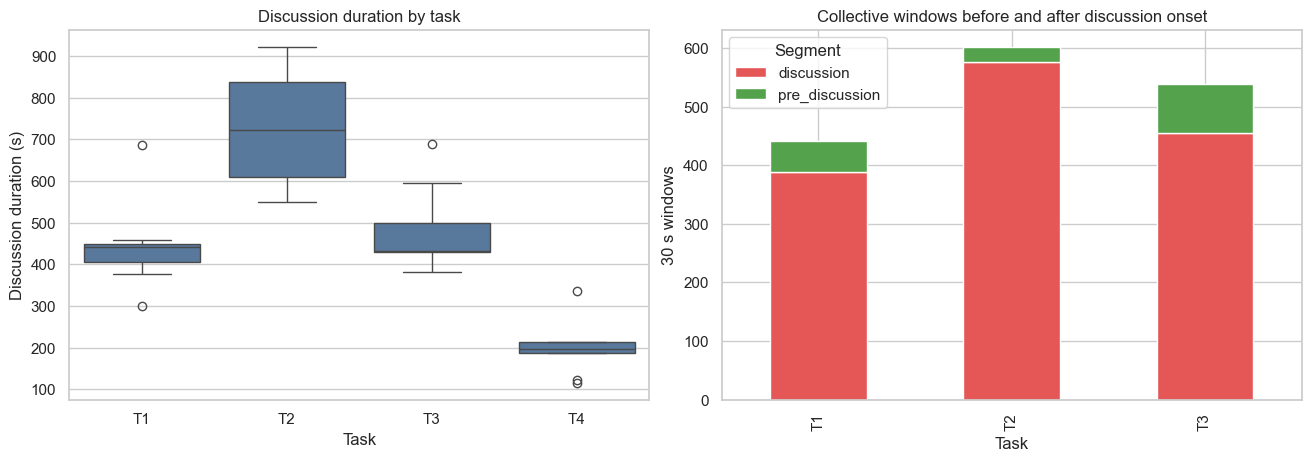

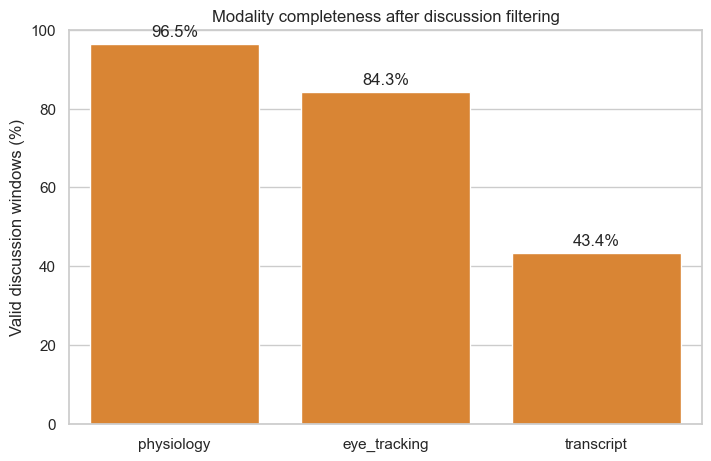

In [4]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
sns.boxplot(
    data=task_timing, x="task_id", y="discussion_duration_s", order=["T1", "T2", "T3", "T4"],
    color="#4C78A8", ax=axes[0]
)
axes[0].set(xlabel="Task", ylabel="Discussion duration (s)", title="Discussion duration by task")

plot_counts = retained_windows.pivot(index="task_id", columns="analysis_segment", values="n_windows").fillna(0)
plot_counts = plot_counts.reindex([task for task in ["T1", "T2", "T3", "T4"] if task in plot_counts.index])
plot_counts.plot(kind="bar", stacked=True, color=["#E45756", "#54A24B"], ax=axes[1])
axes[1].set(xlabel="Task", ylabel="30 s windows", title="Collective windows before and after discussion onset")
axes[1].legend(title="Segment")

fig.savefig(OUTPUT_DIR / "discussion_duration_and_window_filtering.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
sns.barplot(data=modality_completeness, x="modality", y="valid_pct", color="#F58518", ax=ax)
ax.set(xlabel="", ylabel="Valid discussion windows (%)", ylim=(0, 100), title="Modality completeness after discussion filtering")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
fig.savefig(OUTPUT_DIR / "discussion_window_modality_completeness.png", dpi=300, bbox_inches="tight")
plt.show()